# OpenAI embedding_model + LangChain RAG

## Learning Goals

In this notebook, I want to learn how to:

1. Embed `docs/chunks.jsonl` into a vector database using the OpenAI API.
2. Build a retrieval-augmented generation (RAG) workflow on top of that vector database using LangChain.

## Ground Rule

**No code should be written by AI.**

AI can help explain concepts, review errors, and suggest debugging steps, but I will write the implementation myself.


## Step 1: Load The Chunk Data

In [6]:
from pathlib import Path
import json
print(Path.cwd())
chunks_path = Path("../../docs/chunks.jsonl")
chunks_path.exists()

/Users/ericliuuuuuuuu/Personal/TCMagent/src/tcmagent


True

In [9]:
chunks = []

with chunks_path.open("r", encoding= "utf-8") as file:
    for line in file:
        chunk = json.loads(line)
        chunks.append(chunk)

print(len(chunks))
print(chunks[0].keys())
print(chunks[0]["text"])

940
dict_keys(['chunk_id', 'text', 'citation_link', 'pdf_page', 'pdf_page_start', 'pdf_page_end', 'pdf_pages', 'citation_links', 'citation_markdown'])
绪 论中医学，是以中医药理论与实践经验为主体，研究人类生命活动中健康与疾病转化规律及其预防、诊断、治疗、康复和保健的综合性科学。中医学发源于中国，有着数千年悠久历史，是中华民族传统文化的重要组成部分，是中华民族在长期的生产、生活和医疗实践中，认识生命、维护健康、防治疾病宝贵经验的积累和总结，是历代传承并发展创新的原创性医学理论体系，为中华民族的繁衍昌盛做出了巨大的贡献。中医学传播到世界各地，对全人类的健康保健和疾病防治，产生了重要的影响和促进作用。中医学的学科属性是以自然科学为主体，与人文社会科学等多学科相交融的综合性医学科学知识体系。中医学以人—自然 （环境）—社会 （心理）为医学模式。人类的生存与生活必然受到自然环境和社会环境的影响，由此引起一系列有关健康和疾病的医学问题，因此，中医学强调“以人为本”，不仅注重人的生物属性，尤为重视人的心理特征和社会属性，主张顺应自然规律，主动适应自然和社会环境。并且，中医学的研究，注重吸收多学科先进的科学技术，促进学术发展与创新。现代，中医学原创的理论思维、独特的理论体系和丰富的实践经验，在学术发展中不断得到传承和创新，现代化与国际化步伐加快，正在为造福于全人类健康做出新的贡献。


## Step 2: Convert Chunks Into LangChain Documents

In [ ]:
pip install langchain_core

In [14]:
from langchain_core.documents import Document 

documents = [
    Document(
        page_content = chunk["text"],
        metadata = {
            "chunk_id": chunk["chunk_id"],
            "pdf_page": chunk["pdf_page"],
            "citation_markdown": chunk["citation_markdown"],
            "citation_link": chunk["citation_link"],
        }
    ) 
for chunk in chunks
]

documents[3].page_content

'1.中医学理论体系形成的条件\n\n中医学理论体系的形成，经历了一个漫长的历史时期。从春秋战国时期 （公元前770年—公元前221年）到秦汉之际 （公元前221年—公元220年），社会的变革和学术的百家争鸣，为中医学理论体系的形成奠定了社会文化基础。此时，自然科学迅速发展，为中医学理论体系的形成奠定了科学技术基础。古代医家在医学实践与解剖学成就的基础上，以古代哲学的气、阴阳、五行学说作为认识论，创立藏象、经络、精气血津液神等理论，并在探讨人与自然关系的过程中创立六淫、疠气致病学说，在人与社会关系的基础上创立内伤七情等病因学说，以阐释病因、发病和病机，指导疾病的诊断和防治，为中医学理论体系的形成奠定了科学理论与医药实践的基础。'

## Step 3: Create An OpenAI Embedding Model And Test One Embedding.

In [38]:
pip install langchain_openai

Note: you may need to restart the kernel to use updated packages.


In [42]:
from langchain_openai import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(
    model = "text-embedding-3-small",
)

test_vector = embedding_model.embed_query("你好")
print(f"len(test_vector):{len(test_vector)}")
print(test_vector[:5])

len(test_vector):1536
[0.0250701904296875, -0.043487548828125, -0.06463623046875, 0.04583740234375, -0.00010913610458374023]


## Step 4: Save the embeddding into FAISS files

In [33]:
pip install langchain_community faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 12.4 MB/s eta 0:00:0031m9.8 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [46]:
from pathlib import Path 
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(
    documents, 
    embedding_model
)

vectorstore_dir = Path("../../docs/faiss_openai_test_embedding_3_small")
vectorstore.save_local(str(vectorstore_dir))
vectorstore = FAISS.load_local(
    str(vectorstore_dir),
    embedding_model,
    allow_dangerous_deserialization = True
)

## Step 5: Retriving Score Test 

In [64]:
good_questions = [
    "中醫如何理解陰陽失衡造成的疾病？",
    "脾胃在中醫理論中負責哪些生理功能？",
    "什麼是氣血津液，彼此之間有什麼關係？",
    "中醫所說的六淫包含哪些外感病因？",
    "肝鬱氣滯在臨床上可能出現哪些表現？",
    "腎精不足會如何影響人體生長與發育？",
    "飲食不節為什麼會損傷脾胃？",
    "望聞問切四診分別觀察哪些內容？",
    "痰飲在中醫病因病機中如何形成？",
    "寒熱虛實如何用來辨別證候？"
]

bad_questions = [
    "現任美國總統是誰？",
    "台積電股價今天多少？",
    "如何用 Python 讀取 CSV 檔案？",
    "台北明天的天氣預報是什麼？",
    "NBA 總冠軍賽最新比分是多少？",
    "如何規劃東京五天四夜自由行？",
    "披薩麵團需要發酵多久？",
    "第二次世界大戰是哪一年結束的？",
    "如何計算複利投資報酬率？",
    "哪一款筆電適合剪輯 4K 影片？"
]

good_result = [
    vectorstore.similarity_search_with_score(
    question,
    k = 5 
) for question in good_questions
]

bad_result = [
    vectorstore.similarity_search_with_score(
    question,
    k = 5 
) for question in bad_questions
]

good_score, bad_score = 0,0

for result in good_result:
    for document, score in result:
        print(f"score: {score}")
        good_score += score
        # print(document.page_content)
        print("--------------------")

print(f"average_good_score:{good_score/50}")

for result in bad_result:
    for document, score in result:
        print(f"score: {score}")
        bad_score += score
        # print(document.page_content)
        print("--------------------")

print(f"average_bad_score:{bad_score/50}")

score: 0.8207661509513855
--------------------
score: 0.8231754302978516
--------------------
score: 0.8438629508018494
--------------------
score: 0.8504629731178284
--------------------
score: 0.8714717030525208
--------------------
score: 0.7167484760284424
--------------------
score: 0.7609894275665283
--------------------
score: 0.7962827086448669
--------------------
score: 0.8015369176864624
--------------------
score: 0.802734375
--------------------
score: 0.6161520481109619
--------------------
score: 0.6309362053871155
--------------------
score: 0.6594492197036743
--------------------
score: 0.6762274503707886
--------------------
score: 0.7328241467475891
--------------------
score: 0.6564210057258606
--------------------
score: 0.7046686410903931
--------------------
score: 0.7258609533309937
--------------------
score: 0.8702714443206787
--------------------
score: 0.8954966068267822
--------------------
score: 0.885979413986206
--------------------
score: 0.899552226066

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

def collect_scores(results, questions, label):
    rows = []

    for question_id, (question, matches) in enumerate(zip(questions, results), start=1):
        for rank, (doc, score) in enumerate(matches, start=1):
            rows.append({
                "label": label,
                "question_id": question_id,
                "question": question,
                "rank": rank,
                "score": score,
            })

    return rows

score_df = pd.DataFrame(
    collect_scores(good_result, good_questions, "TCM") +
    collect_scores(bad_result, bad_questions, "Not TCM")
)

score_df.groupby("label")["score"].describe()

Matplotlib is building the font cache; this may take a moment.


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Not TCM,50.0,1.650748,0.065293,1.481554,1.604504,1.654834,1.687575,1.770668
TCM,50.0,0.856728,0.136329,0.616152,0.741515,0.860156,0.956602,1.142059


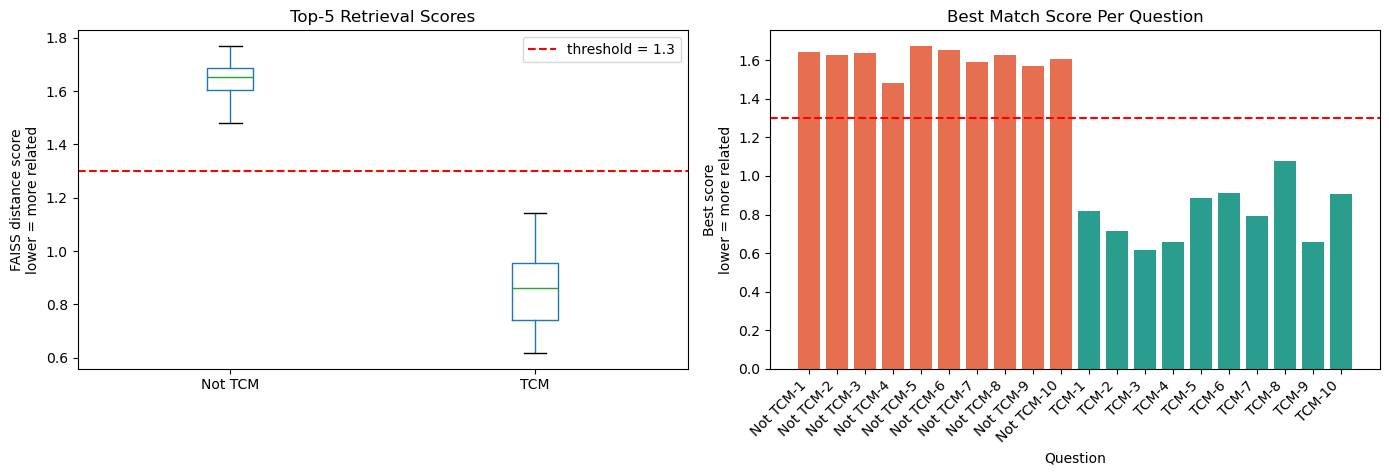

In [66]:
MAX_DISTANCE = 1.3 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


score_df.boxplot(
    column="score",
    by="label",
    ax=axes[0],
    grid=False
)
axes[0].set_title("Top-5 Retrieval Scores")
axes[0].set_xlabel("")
axes[0].set_ylabel("FAISS distance score\nlower = more related")
axes[0].axhline(MAX_DISTANCE, color="red", linestyle="--", label=f"threshold = {MAX_DISTANCE}")
axes[0].legend()

best_scores = (
    score_df
    .groupby(["label", "question_id"], as_index=False)["score"]
    .min()
)

colors = best_scores["label"].map({
    "TCM": "#2a9d8f",
    "Not TCM": "#e76f51",
})

axes[1].bar(range(len(best_scores)), best_scores["score"], color=colors)
axes[1].set_title("Best Match Score Per Question")
axes[1].set_xlabel("Question")
axes[1].set_ylabel("Best score\nlower = more related")
axes[1].axhline(MAX_DISTANCE, color="red", linestyle="--")

axes[1].set_xticks(range(len(best_scores)))
axes[1].set_xticklabels(
    [f"{row.label}-{row.question_id}" for row in best_scores.itertuples()],
    rotation=45,
    ha="right"
)

plt.suptitle("")
plt.tight_layout()
plt.show()

## Step 6: Answer Question 

In [49]:
MAX_DISTANCE = 1.3

def format_context (docs):
    blocks = []

    for i, doc in enumerate(docs, start = 1):
        citation = doc.metadata["citation_markdown"]
        text = doc.page_content 

        blocks.append(
            f"[Source {i}] {citation}\n {text}"
        )
    
    return "\n\n".join(blocks)

In [58]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

question = "一杯咖啡大概賣多少"

result = vectorstore.similarity_search_with_score(question, k = 5)

kept_result = [doc for doc, score in result if score < MAX_DISTANCE]

print(len(kept_result))



0


In [59]:
from IPython.display import display, Markdown

prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "你是一名中醫諮詢師"
        "若有 context，根據所有你得到的 context 回答，且必須附上所有 citation"
    ),
    (
        "user",
        "問題：\n{question}\n\nContext:\n{context}"
    )
])

llm = ChatOpenAI(
    model = "gpt-4o-mini",
)

chain = prompt | llm | StrOutputParser()

answer = chain.invoke({
    "question": question,
    "context": format_context(kept_result)
})

display(Markdown(answer))


抱歉，您提供的問題缺少足夠的上下文信息。關於一杯咖啡的價格，這取決於多種因素，包括地點、咖啡的種類、品牌以及是否添加了額外的配料（如牛奶、香料等）。一般來說，在美國，一杯普通的黑咖啡可能價格在2到5美元之間，而專業咖啡館中的特調咖啡可能會更高。如果您能提供更具體的上下文，將有助於我來回答您的問題。

## Similarity Matrix

In [ ]:
import numpy as np

sample_docs = documents[:5]
texts = [doc.page_content for doc in sample_docs]
vectors = []
for text in texts: 
    vectors.append(embedding_model.embed_query(text)) 
    print("complete")

complete
complete
complete
complete
complete


In [29]:
X = np.array(vectors)
print(X.shape)
X_normed = X / np.linalg.norm(X, axis = 1 , keepdims = True)

similarity_matrix = X_normed @ X_normed.T

similarity_matrix

(5, 1536)


array([[1.        , 0.56835545, 0.54150547, 0.6953988 , 0.61760245],
       [0.56835545, 1.        , 0.70607168, 0.7839701 , 0.57845852],
       [0.54150547, 0.70607168, 1.        , 0.79702532, 0.61580106],
       [0.6953988 , 0.7839701 , 0.79702532, 1.        , 0.71427108],
       [0.61760245, 0.57845852, 0.61580106, 0.71427108, 1.        ]])